In [16]:
import pandas as pd
import numpy as np
import warnings
from copy import deepcopy
from rxnpredict.ts.desc import sel_satisfy_ts_data,vec_ts_pair_in_dataset,get_diff_ts_desc,load_map
from rxnpredict.models.utils import get_model
from rxnpredict.evaluate.eval import get_val_score_add_data,get_predict,get_topk_rxn_comb_df
from rxnpredict.descriptors.desc import vect_columns_in_dataset,sel_high_corr_desc,reduce_desc_with_corr_matrix
from rxnpredict.descriptors.utils import process_desc,maxminscale
from rdkit import RDLogger
from rxnpredict.utils.convert import ddG2ee
from rxnpredict.descriptors.utils import canonical_smiles
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,r2_score
from scipy.stats import pearsonr
import itertools, optuna
from optuna.samplers import TPESampler
from functools import partial
from rxnpredict.models.hyperopt import gb_objective
from sklearn.feature_selection import RFECV
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt
RDLogger.DisableLog('rdApp.*')
warnings.filterwarnings('ignore')

### Read feature selection result

{(0,): 0.6714320131795922, (0, 53): 0.6827624159245324, (0, 53, 1): 0.697528939083538, (0, 53, 1, 42): 0.7012674958555238, (0, 53, 1, 42, 5): 0.7066330503131557, (0, 53, 1, 42, 5, 2): 0.7343675135060412, (0, 53, 1, 42, 5, 2, 21): 0.7494178603613926, (0, 53, 1, 42, 5, 2, 21, 172): 0.7813588887800107, (): 0.6510393169986792}



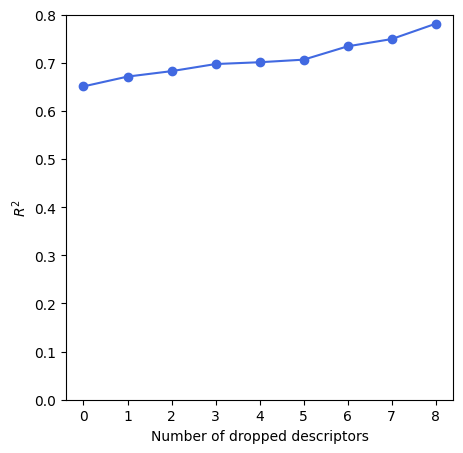

In [38]:
feat_selection_res = np.load("./results/dropped_idx_score_map_0.7813588887800107.npy",allow_pickle=True).item()
feat_selection_res[()] = 0.6510393169986792
drop_feat_num_r2_lst = sorted([[len(key), feat_selection_res[key]] for key in feat_selection_res.keys()],key=lambda x:x[0])
print(feat_selection_res)
plt.figure(figsize=(5,5))
plt.ylim(0,0.8)
plt.plot([x[0] for x in drop_feat_num_r2_lst], [x[1] for x in drop_feat_num_r2_lst], marker='o', c='royalblue')
plt.xlabel("Number of dropped descriptors")
plt.ylabel("$R^2$")
print()

### Read data

In [2]:
model_name = "GradientBoostingRegressor"
desc_name = "SPOC"
merge_method = "delta"
topk = 300
dist_type = "euclidean"
descriptor_pearsonr_threshold = 0.95
descriptor_target_pearsonr_threshold = 0.2
base_rct_keys = ["Reactant1","Reactant2"]
target_rct_keys = ["Reactant1","Reactant2"]
base_sol_keys = ["Solvents"]
target_sol_keys = ["Solvents"]
base_rgt_keys = ["Reagents"]
target_rgt_keys = ["Reagents"]
base_ts_key = ["Reactant2","Reagent5"]
target_ts_key = ["Reactant2","Reagent2"]
selection_inf = {
            "type": "loo",
            "fold": 10,
            "metric": [
                "r2",
                "mae"
            ]}

In [3]:
n_trials = 15
random_state = 1024

In [4]:
base_data_file = "../data/base_data.csv"
target_data_file = "../data/target_data.csv"
base_data = pd.read_csv(base_data_file)
target_data = pd.read_csv(target_data_file)
base_data_clean = base_data.dropna(axis=1, how='all')
target_data_clean = target_data.dropna(axis=1, how='all')

# fill NaN with empty string
for key in target_rct_keys + target_sol_keys + target_rgt_keys:
    target_data_clean[key] = target_data_clean[key].fillna('')
for key in base_rct_keys + base_sol_keys + base_rgt_keys:
    base_data_clean[key] = base_data_clean[key].fillna('')
## Drop rows with missing target values
target_data_clean = target_data_clean.dropna(subset=target_rct_keys+target_ts_key)
base_data_clean = base_data_clean.dropna(subset=base_rct_keys+base_ts_key)
clear_smiles_tsdesc_map = np.load("../desc/clear_smiles_tsdesc_map.npy",allow_pickle=True).item()
print(f"base data shape: {base_data_clean.shape}", f"target data shape: {target_data_clean.shape}")

base data shape: (466, 16) target data shape: (68, 12)


In [5]:
sel_target_data_clean = target_data_clean.iloc[sel_satisfy_ts_data(target_data_clean,target_ts_key,clear_smiles_tsdesc_map)]
sel_base_data_clean = base_data_clean.iloc[sel_satisfy_ts_data(base_data_clean,base_ts_key,clear_smiles_tsdesc_map)]
print(f"Dataset size: target = {target_data_clean.shape} (without ts constraint) {sel_target_data_clean.shape} (with ts constraint), base = {base_data_clean.shape} (without ts constraint) {sel_base_data_clean.shape} (with ts constraint)")

# perform vectorization for target values with ts descriptors
target_ts_desc_inf = vec_ts_pair_in_dataset(sel_target_data_clean,target_ts_key,clear_smiles_tsdesc_map)
target_ts_desc,target_ts_desc_names = target_ts_desc_inf[:,0,:].astype(np.float32),target_ts_desc_inf[:,1,:]
base_ts_desc_inf = vec_ts_pair_in_dataset(sel_base_data_clean,base_ts_key,clear_smiles_tsdesc_map)
base_ts_desc,base_ts_desc_names = base_ts_desc_inf[:,0,:].astype(np.float32),base_ts_desc_inf[:,1,:]
print(f"target TS descriptor shape: {target_ts_desc.shape}, name shape: {target_ts_desc_names.shape}, base TS descriptor shape: {base_ts_desc.shape}, name shape: {base_ts_desc_names.shape}")


# calculate difference descriptors between R/S TS
target_ts_diff_desc,target_ts_diff_desc_names = get_diff_ts_desc(target_ts_desc,target_ts_desc_names[0])
base_ts_diff_desc,base_ts_diff_desc_names = get_diff_ts_desc(base_ts_desc,base_ts_desc_names[0])
target_ts_desc = np.concatenate([target_ts_desc,target_ts_diff_desc],axis=1)                                             ## full TS descriptors
base_ts_desc = np.concatenate([base_ts_desc,base_ts_diff_desc],axis=1)                                                   ## full TS descriptors
target_ts_desc_names = np.concatenate([target_ts_desc_names[0],target_ts_diff_desc_names],axis=0)                        ## full TS descriptor names
base_ts_desc_names = np.concatenate([base_ts_desc_names[0],base_ts_diff_desc_names],axis=0)                              ## full TS descriptor names
target_ddG = sel_target_data_clean["ddG"].to_numpy()
base_ddG = sel_base_data_clean["ddG"].to_numpy()
print(f"Full target TS descriptor shape: {target_ts_desc.shape}, name shape: {target_ts_desc_names.shape}, base TS descriptor shape: {base_ts_desc.shape}, name shape: {base_ts_desc_names.shape}")

Dataset size: target = (68, 12) (without ts constraint) (55, 12) (with ts constraint), base = (466, 16) (without ts constraint) (446, 16) (with ts constraint)
target TS descriptor shape: (55, 114), name shape: (55, 114), base TS descriptor shape: (446, 114), name shape: (446, 114)
Full target TS descriptor shape: (55, 171), name shape: (171,), base TS descriptor shape: (446, 171), name shape: (171,)


In [6]:
pregen_desc_map = np.load("../desc/desc_for_other_components.npy",allow_pickle=True).item()

# descriptor process
concat_ts_desc,concat_ts_desc_process_ret_idx = process_desc(np.concatenate([target_ts_desc,base_ts_desc],axis=0),return_idx=True)                                                                              # descriptor process
concat_ts_desc,concat_ts_desc_max,concat_ts_desc_min = maxminscale(concat_ts_desc,return_scale=True)                                                                                                            # descriptor process
# remove correlated descriptors
concat_ts_desc,concat_ts_desc_high_tgt_corr_idx = sel_high_corr_desc(concat_ts_desc,np.concatenate([target_ddG,base_ddG]),threshold=descriptor_target_pearsonr_threshold,return_idx=True)                       # descriptor elimination
concat_ts_desc,concat_ts_desc_high_corr_idx = reduce_desc_with_corr_matrix(concat_ts_desc,threshold=descriptor_pearsonr_threshold,ret_idx=True)                                                                 # descriptor elimination

target_ts_desc_ = concat_ts_desc[:target_ts_desc.shape[0]]
base_ts_desc_ = concat_ts_desc[target_ts_desc.shape[0]:]
print(f"target_ts_desc shape: {target_ts_desc.shape}, base_ts_desc shape: {base_ts_desc.shape}")
print(f"target_ts_desc_ shape: {target_ts_desc_.shape},  base_ts_desc_ shape: {base_ts_desc_.shape}")


target_merg_rxn_desc = pregen_desc_map[desc_name]["target"]
base_merg_rxn_desc = pregen_desc_map[desc_name]["base"]
concat_merge_rxn_desc, concat_merge_rxn_desc_process_ret_idx = process_desc(np.concatenate([target_merg_rxn_desc,base_merg_rxn_desc],axis=0),return_idx=True)                                                               # descriptor process
concat_merge_rxn_desc,concat_merge_rxn_desc_max,concat_merge_rxn_desc_min = maxminscale(concat_merge_rxn_desc,return_scale=True)                                                                                            # descriptor process
concat_merge_rxn_desc,concat_merge_rxn_desc_high_tgt_corr_idx = sel_high_corr_desc(concat_merge_rxn_desc,np.concatenate([target_ddG,base_ddG]),threshold=descriptor_target_pearsonr_threshold,return_idx=True)              # descriptor elimination
concat_merge_rxn_desc,concat_merge_rxn_desc_high_corr_idx = reduce_desc_with_corr_matrix(concat_merge_rxn_desc,threshold=descriptor_pearsonr_threshold,ret_idx=True)                                                        # descriptor process

target_merg_rxn_desc_ = concat_merge_rxn_desc[:target_merg_rxn_desc.shape[0]]
base_merg_rxn_desc_ = concat_merge_rxn_desc[target_merg_rxn_desc.shape[0]:]
print(f"{desc_name} target_merg_rxn_desc shape: {target_merg_rxn_desc.shape}, base_merg_rxn_desc shape: {base_merg_rxn_desc.shape}")
print(f"{desc_name} target_merg_rxn_desc_ shape: {target_merg_rxn_desc_.shape},  base_merg_rxn_desc_ shape: {base_merg_rxn_desc_.shape}")

target_full_rxn_desc = np.concatenate([target_merg_rxn_desc_,target_ts_desc_],axis=1)                       # TS + other component descriptors
base_full_rxn_desc = np.concatenate([base_merg_rxn_desc_,base_ts_desc_],axis=1)                             # TS + other component descriptors

full_rxn_desc_std, full_rxn_desc_process_ret_idx = process_desc(np.concatenate([target_full_rxn_desc,base_full_rxn_desc],axis=0),return_idx=True)
full_rxn_desc_std, full_rxn_desc_max, full_rxn_desc_min = maxminscale(full_rxn_desc_std,return_scale=True)

target_full_rxn_desc_ = full_rxn_desc_std[:target_full_rxn_desc.shape[0]]
base_full_rxn_desc_ = full_rxn_desc_std[target_full_rxn_desc.shape[0]:]

target_ts_desc shape: (55, 171), base_ts_desc shape: (446, 171)
target_ts_desc_ shape: (55, 67),  base_ts_desc_ shape: (446, 67)
SPOC target_merg_rxn_desc shape: (55, 9032), base_merg_rxn_desc shape: (446, 9032)
SPOC target_merg_rxn_desc_ shape: (55, 193),  base_merg_rxn_desc_ shape: (446, 193)


### Hyperparameter optimization

In [15]:
sampler = TPESampler(n_startup_trials=5, seed=random_state)
study = optuna.create_study(direction='maximize',sampler=sampler)
optimize_func = partial(gb_objective, base_X=base_full_rxn_desc_,base_y=base_ddG,X=target_full_rxn_desc_,y=target_ddG,
                                selection_inf=selection_inf,random_state=random_state,
                                merge_method=merge_method,topk=topk,dist_type=dist_type)
study.optimize(optimize_func, n_trials=n_trials)
best_model = GradientBoostingRegressor(**study.best_params, random_state=random_state)

[I 2025-12-24 00:43:39,264] A new study created in memory with name: no-name-c9b601aa-7355-46ea-9880-70094dfd8991


Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 300


[I 2025-12-24 00:48:18,895] Trial 0 finished with value: -0.021796149987500346 and parameters: {'n_estimators': 212, 'min_samples_split': 6, 'max_depth': 33}. Best is trial 0 with value: -0.021796149987500346.


Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 300


[I 2025-12-24 00:52:18,311] Trial 1 finished with value: -0.1916997311907298 and parameters: {'n_estimators': 215, 'min_samples_split': 4, 'max_depth': 46}. Best is trial 0 with value: -0.021796149987500346.


...

[I 2025-12-24 01:17:25,697] Trial 12 finished with value: 0.6510393169986792 and parameters: {'n_estimators': 117, 'min_samples_split': 5, 'max_depth': 3}. Best is trial 12 with value: 0.6510393169986792.


Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 300


[I 2025-12-24 01:20:30,504] Trial 13 finished with value: -0.0824762192924755 and parameters: {'n_estimators': 165, 'min_samples_split': 5, 'max_depth': 17}. Best is trial 12 with value: 0.6510393169986792.


Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 300


[I 2025-12-24 01:20:52,323] Trial 14 finished with value: 0.5978304843555693 and parameters: {'n_estimators': 50, 'min_samples_split': 3, 'max_depth': 3}. Best is trial 12 with value: 0.6510393169986792.


In [18]:
print(study.best_params)
best_model = GradientBoostingRegressor(**study.best_params, random_state=random_state)

{'n_estimators': 117, 'min_samples_split': 5, 'max_depth': 3}


In [40]:
tgt_lig_lst = sel_target_data_clean["Reagent2"].to_list()
tgt_rgt_lst = sel_target_data_clean["Reagents"].to_list()
tgt_rgt1_lst = sorted(list(set(sel_target_data_clean["Reagent1"].to_list())))
tgt_rgt2_lst = sorted(list(set(sel_target_data_clean["Reagent3"].to_list())))
tgt_rgt3_lst = sorted(list(set(sel_target_data_clean["Reagent4"].to_list())))
tgt_sol_lst = sel_target_data_clean["Solvents"].to_list()
proposed_lig_smi_set = pd.read_csv("../data/proposed_ligand_library.csv")["SMILES"].to_list()
lig_lst = [item.split(",")[1] for item in list(load_map("../data/smi_idx_map.csv").keys())]
rgt_set = sorted([canonical_smiles(".".join([rgt1,rgt2,rgt3])) for rgt1,rgt2,rgt3 in itertools.product(tgt_rgt1_lst,tgt_rgt2_lst,tgt_rgt3_lst)])

lig_set = sorted(list(set(sel_target_data_clean["Reagent2"].to_list() + sel_base_data_clean["Reagent5"].to_list() + proposed_lig_smi_set + lig_lst)))
sol_set = sorted(list(set(tgt_sol_lst)))
print(f"ligand count: {len(lig_set)}, reagent count: {len(rgt_set)}")
tot_comb = list(itertools.product(lig_set,rgt_set,sol_set))
tot_comb = [(item[0],canonical_smiles(f"{item[0]}.{item[1]}"),item[2]) for item in tot_comb] 
existed_comb = [(lig,rgt,sol) for lig,rgt,sol in zip(tgt_lig_lst,tgt_rgt_lst,tgt_sol_lst)]
ret_comb = [comb for comb in tot_comb if comb not in existed_comb]
print(f"Total combinations: {len(tot_comb)}, existed combinations: {len(existed_comb)}, new combinations: {len(ret_comb)}")

vir_comb = ret_comb
ret_vir_comb_df = pd.DataFrame({"Reactant1": [sel_target_data_clean["Reactant1"][0]] * len(vir_comb),
                            "Reactant2": [sel_target_data_clean["Reactant2"][0]] * len(vir_comb),
                            "Ligand": [lig for lig,rgt,sol in vir_comb],
                            "Reagents": [rgt for lig,rgt,sol in vir_comb],  
                            "Solvents": [sol for lig,rgt,sol in vir_comb]})
sel_vir_idx = sel_satisfy_ts_data(ret_vir_comb_df,["Reactant2","Ligand"],clear_smiles_tsdesc_map,verbose=False)
miss_vir_idx = list(set(range(0,ret_vir_comb_df.shape[0])) - set(sel_vir_idx))
sel_vir_comb_df = ret_vir_comb_df.iloc[sel_vir_idx,:]
miss_vir_comb_df = ret_vir_comb_df.iloc[miss_vir_idx,:]
print(f"Size of selected virtual combinations: {sel_vir_comb_df.shape[0]}")
print(f"Size of missing virtual combinations: {miss_vir_comb_df.shape[0]}")

ligand count: 85, reagent count: 6
Total combinations: 510, existed combinations: 55, new combinations: 455
Size of selected virtual combinations: 431
Size of missing virtual combinations: 24


In [41]:
# descriptor for other components
vir_merg_rct_desc,_,_ = vect_columns_in_dataset(sel_vir_comb_df,["Reactant1","Reactant2"],{'descriptor':desc_name},verbose=True)
vir_merg_sol_desc,_,_ = vect_columns_in_dataset(sel_vir_comb_df,["Solvents"],{'descriptor':desc_name},verbose=True)
vir_merg_reag_desc,_,_ = vect_columns_in_dataset(sel_vir_comb_df,["Reagents"],{'descriptor':desc_name},verbose=True)

vir_merg_rxn_desc = np.concatenate([vir_merg_rct_desc,vir_merg_sol_desc,vir_merg_reag_desc],axis=1)
# descriptor for TS
vir_ts_desc_inf = vec_ts_pair_in_dataset(sel_vir_comb_df,["Reactant2","Ligand"],clear_smiles_tsdesc_map)
vir_ts_desc,vir_ts_desc_names = vir_ts_desc_inf[:,0,:].astype(np.float32),vir_ts_desc_inf[:,1,:]

# calculate difference descriptors between R/S TS
vir_ts_diff_desc,vir_ts_diff_desc_names = get_diff_ts_desc(vir_ts_desc,vir_ts_desc_names[0])
vir_ts_desc = np.concatenate([vir_ts_desc,vir_ts_diff_desc],axis=1)                                             ## full TS descriptors

vir_ts_desc_ = ((vir_ts_desc[:,concat_ts_desc_process_ret_idx]-concat_ts_desc_min) / (concat_ts_desc_max-concat_ts_desc_min))[:,concat_ts_desc_high_tgt_corr_idx][:,concat_ts_desc_high_corr_idx]     
#vir_merg_rxn_desc_ = 
vir_merg_rxn_desc_ = ((vir_merg_rxn_desc[:,concat_merge_rxn_desc_process_ret_idx]-concat_merge_rxn_desc_min) / (concat_merge_rxn_desc_max-concat_merge_rxn_desc_min))[:,concat_merge_rxn_desc_high_tgt_corr_idx][:,concat_merge_rxn_desc_high_corr_idx]
vir_full_rxn_desc = (np.concatenate([vir_merg_rxn_desc_,vir_ts_desc_],axis=1)[:,full_rxn_desc_process_ret_idx] - full_rxn_desc_min) / (full_rxn_desc_max-full_rxn_desc_min)  ## final descriptor
print(vir_full_rxn_desc.max(axis=0).max(),vir_full_rxn_desc.min(axis=0).min())

4.0 -0.6956223249435425


In [7]:
model = GradientBoostingRegressor(n_estimators=117, min_samples_split=5, max_depth=3, random_state=1024)
dropped_feat_idx_lst = [0, 53, 1, 42, 5, 2, 21, 172]
remained_feat_idx_lst = [i for i in range(base_full_rxn_desc_.shape[1]) if i not in dropped_feat_idx_lst]
va_Y,va_P,score_map = get_val_score_add_data(model,base_full_rxn_desc_[:,remained_feat_idx_lst],base_ddG,
                                             target_full_rxn_desc_[:,remained_feat_idx_lst],target_ddG,
                                             selection_inf=selection_inf,merge_method=merge_method,topk=topk,dist_type=dist_type)
print(f"score map: {score_map}")

Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 300
score map: {'r2': 0.7813588887800107, 'mae': 0.16055078585490806}


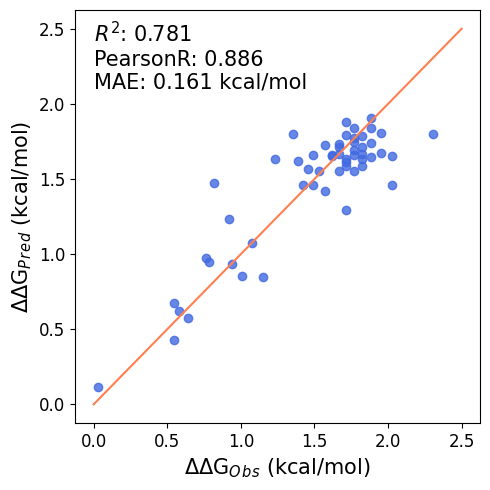

In [9]:
label_fontsize = 15
tick_fontsize = 12
plt.figure(figsize=(5,5))
plt.scatter(va_Y,va_P,color='royalblue',alpha=0.8)
plt.plot([0,2.5],[0,2.5],color='coral')
plt.xlabel('ΔΔG$_O$$_b$$_s$ (kcal/mol)',fontsize=label_fontsize)
plt.ylabel('ΔΔG$_P$$_r$$_e$$_d$ (kcal/mol)',fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.text(0.0,2.1,f'$R^2$: {r2_score(va_Y,va_P):.3f}\nPearsonR: {pearsonr(va_Y,va_P)[0]:.3f}\nMAE: {mean_absolute_error(va_Y,va_P):.3f} kcal/mol',fontsize=15)
plt.tight_layout()

### Distance topk opt and recommend

In [35]:
topk_lst = [100,200,300,400,500]
topk_r2_lst = []
for topk_ in topk_lst:
    va_Y,va_P,score_map = get_val_score_add_data(model,base_full_rxn_desc_[:,remained_feat_idx_lst],base_ddG,
                                             target_full_rxn_desc_[:,remained_feat_idx_lst],target_ddG,
                                             selection_inf=selection_inf,merge_method=merge_method,topk=topk_,dist_type=dist_type)
    print(topk_,score_map['r2'])
    topk_r2_lst.append([topk_,score_map['r2']])

Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 100
100 0.3542418998887895
Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 200
200 0.4175705707730346
Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 300
300 0.7813588887800107
Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 400
400 0.47786164833074496
Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 500
500 0.38736061813915446


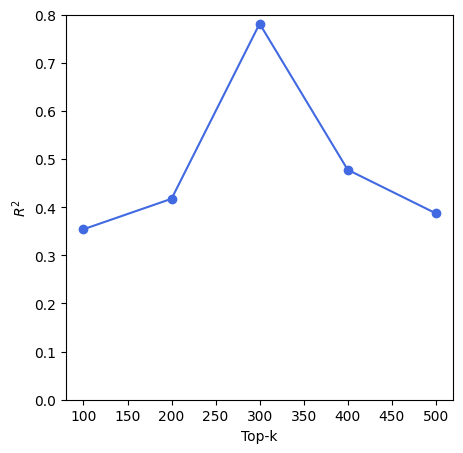

In [37]:
plt.figure(figsize=(5,5))
plt.plot([x[0] for x in topk_r2_lst], [x[1] for x in topk_r2_lst], marker='o', c='royalblue')
plt.ylim(0,0.8)
plt.xlabel("Top-k")
plt.ylabel("$R^2$")
print()

### Reaction recommendation

In [42]:
vir_P = get_predict(model,base_full_rxn_desc_[:,remained_feat_idx_lst],base_ddG,
                    target_full_rxn_desc_[:,remained_feat_idx_lst],target_ddG,
                    vir_full_rxn_desc[:,remained_feat_idx_lst],merge_method=merge_method,simi_eval=True,
                    dist_type=dist_type,topk=topk,base_simi_X=None,dest_simi_X=None,verbose=True)
vir_ee = ddG2ee(vir_P,60+273.15)
sel_vir_comb_df["Predict_ddG"] = vir_P
sel_vir_comb_df["Predict_ee"] = vir_ee
topk_recommend_res = get_topk_rxn_comb_df(sel_vir_comb_df,"Predict_ddG",topk=10)
topk_rgts = topk_recommend_res["Reagents"].to_list()
topk_ddG = topk_recommend_res["Predict_ddG"].to_numpy()
topk_ee = ddG2ee(topk_ddG,60+273.15)

Evalutaion process: merge method delta, similarity evaluation True, distance type euclidean, topk 300
323 times model fitting


In [43]:
topk_recommend_res.to_csv("../recommend/top10_recommend_reacton.csv",index=False)
topk_recommend_res

,Reactant1,Reactant2,Ligand,Reagents,Solvents,Predict_ddG,Predict_ee
403,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,Cc1ccccc1C[C@H](NC(=O)OC(C)(C)C)C(=O)O,CC(=O)O[Pd]OC(C)=O.CCCC[N+](CCCC)(CCCC)CCCC.Cc...,CN(C)C=O,2.416399,0.949169
199,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,CC(C)(C)OC(=O)N[C@@H](Cc1ccn(COCc2ccccc2)c1)C(...,CC(=O)O[Pd]OC(C)=O.CC(C)(C)OC(=O)N[C@@H](Cc1cc...,CN(C)C=O,2.395940,0.947617
119,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,CC(C)(C)OC(=O)N[C@@H](Cc1cc(F)cc(F)c1)C(=O)O,CC(=O)O[Pd]OC(C)=O.CC(C)(C)OC(=O)N[C@@H](Cc1cc...,CN(C)C=O,2.278554,0.937781
122,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,CC(C)(C)OC(=O)N[C@@H](Cc1cc(F)cc(F)c1)C(=O)O,CC(=O)O[Pd]OC(C)=O.CC(C)(C)OC(=O)N[C@@H](Cc1cc...,CN(C)C=O,2.243489,0.934510
201,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,CC(C)(C)OC(=O)N[C@@H](Cc1ccn(COCc2ccccc2)c1)C(...,CC(=O)O[Pd]OC(C)=O.CC(C)(C)OC(=O)N[C@@H](Cc1cc...,CN(C)C=O,2.195397,0.929754
381,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,C[C@H](OCc1ccccc1)[C@H](NC(=O)OC(C)(C)C)C(=O)O,CC(=O)O[Pd]OC(C)=O.CCCC[N+](CCCC)(CCCC)CCCC.C[...,CN(C)C=O,2.149577,0.924913
200,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,CC(C)(C)OC(=O)N[C@@H](Cc1ccn(COCc2ccccc2)c1)C(...,CC(=O)O[Pd]OC(C)=O.CC(C)(C)OC(=O)N[C@@H](Cc1cc...,CN(C)C=O,2.070502,0.915797
264,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,CC(C)C[C@H](NC(=O)OC(C)(C)C)C(=O)O,CC(=O)O[Pd]OC(C)=O.CC(C)C[C@H](NC(=O)OC(C)(C)C...,CN(C)C=O,2.056400,0.914063
120,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,CC(C)(C)OC(=O)N[C@@H](Cc1cc(F)cc(F)c1)C(=O)O,CC(=O)O[Pd]OC(C)=O.CC(C)(C)OC(=O)N[C@@H](Cc1cc...,CN(C)C=O,2.038964,0.911873
31,C=CC(=O)N(C)C,CN1CC23C4C5C6C2[Fe]56432789C3C2C7C8(C1)C39,CC(C)(C)C[C@H](NC(=O)OC(C)(C)C)C(=O)O,CC(=O)O[Pd]OC(C)=O.CC(C)(C)C[C@H](NC(=O)OC(C)(...,CN(C)C=O,2.029093,0.910609


In [47]:
recommend_res_ee_higher_than_90 = sel_vir_comb_df[sel_vir_comb_df['Predict_ee']>0.9]

In [54]:
ee_higher_than_90_rgts = recommend_res_ee_higher_than_90['Reagents'].to_list()
base_ct_map = {'K':0,'Li':0,'Na':0,'Rb':0,'Cs':0}
for rgt in ee_higher_than_90_rgts:
    for base in base_ct_map:
        if base in rgt:
            base_ct_map[base] += 1
            break
base_ct_map

{'K': 3, 'Li': 2, 'Na': 1, 'Rb': 10, 'Cs': 2}

In [57]:
for key in base_ct_map:
    print(key,base_ct_map[key],base_ct_map[key]/sum(base_ct_map.values()))

K 3 0.16666666666666666
Li 2 0.1111111111111111
Na 1 0.05555555555555555
Rb 10 0.5555555555555556
Cs 2 0.1111111111111111


In [60]:
get_topk_rxn_comb_df(sel_vir_comb_df,"Predict_ddG",topk=18)['Reagents'].to_list()

['CC(=O)O[Pd]OC(C)=O.CCCC[N+](CCCC)(CCCC)CCCC.Cc1ccccc1C[C@H](NC(=O)OC(C)(C)C)C(=O)O.O=C([O-])[O-].[Br-].[Rb+].[Rb+]',
 'CC(=O)O[Pd]OC(C)=O.CC(C)(C)OC(=O)N[C@@H](Cc1ccn(COCc2ccccc2)c1)C(=O)O.CCCC[N+](CCCC)(CCCC)CCCC.O=C([O-])[O-].[Br-].[K+].[K+]',
 'CC(=O)O[Pd]OC(C)=O.CC(C)(C)OC(=O)N[C@@H](Cc1cc(F)cc(F)c1)C(=O)O.CCCC[N+](CCCC)(CCCC)CCCC.O=C([O-])[O-].[Br-].[K+].[K+]',
 'CC(=O)O[Pd]OC(C)=O.CC(C)(C)OC(=O)N[C@@H](Cc1cc(F)cc(F)c1)C(=O)O.CCCC[N+](CCCC)(CCCC)CCCC.O=C([O-])[O-].[Br-].[Rb+].[Rb+]',
 'CC(=O)O[Pd]OC(C)=O.CC(C)(C)OC(=O)N[C@@H](Cc1ccn(COCc2ccccc2)c1)C(=O)O.CCCC[N+](CCCC)(CCCC)CCCC.O=C([O-])[O-].[Br-].[Na+].[Na+]',
 'CC(=O)O[Pd]OC(C)=O.CCCC[N+](CCCC)(CCCC)CCCC.C[C@H](OCc1ccccc1)[C@H](NC(=O)OC(C)(C)C)C(=O)O.O=C([O-])[O-].[Br-].[Rb+].[Rb+]',
 'CC(=O)O[Pd]OC(C)=O.CC(C)(C)OC(=O)N[C@@H](Cc1ccn(COCc2ccccc2)c1)C(=O)O.CCCC[N+](CCCC)(CCCC)CCCC.O=C([O-])[O-].[Br-].[Li+].[Li+]',
 'CC(=O)O[Pd]OC(C)=O.CC(C)C[C@H](NC(=O)OC(C)(C)C)C(=O)O.CCCC[N+](CCCC)(CCCC)CCCC.O=C([O-])[O-].[Br-].[Cs+].[Cs+]',
